In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [4]:
df.shape

(74111, 29)

In [5]:
df.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64

In [6]:
df.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


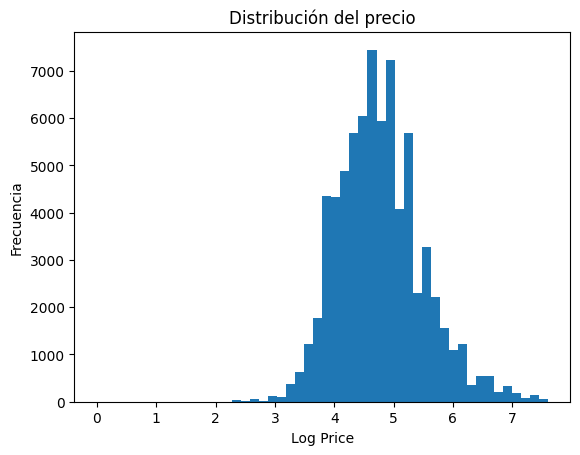

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["log_price"], bins=50)
plt.title("Distribución del precio")
plt.xlabel("Log Price")
plt.ylabel("Frecuencia")
plt.show()

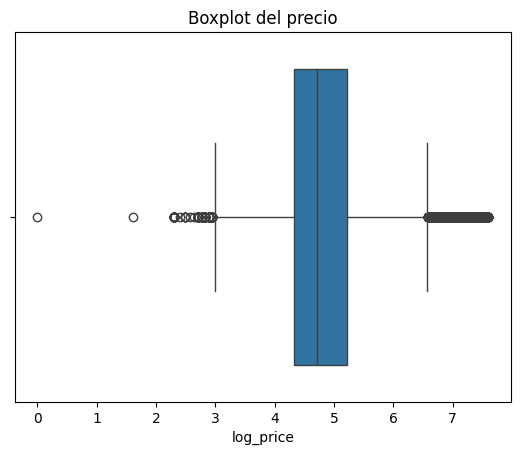

In [8]:
import seaborn as sns

sns.boxplot(x=df["log_price"])
plt.title("Boxplot del precio")
plt.show()

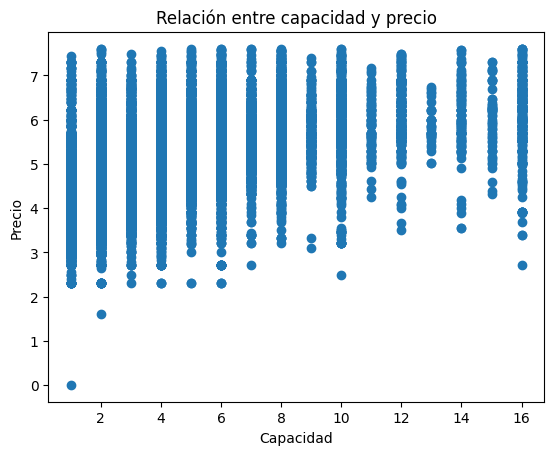

In [9]:
plt.scatter(df["accommodates"], df["log_price"])
plt.xlabel("Capacidad")
plt.ylabel("Precio")
plt.title("Relación entre capacidad y precio")
plt.show()

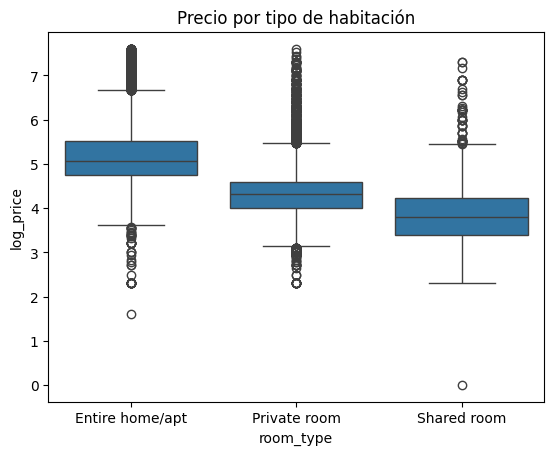

In [10]:
sns.boxplot(x="room_type", y="log_price", data=df)
plt.title("Precio por tipo de habitación")
plt.show()

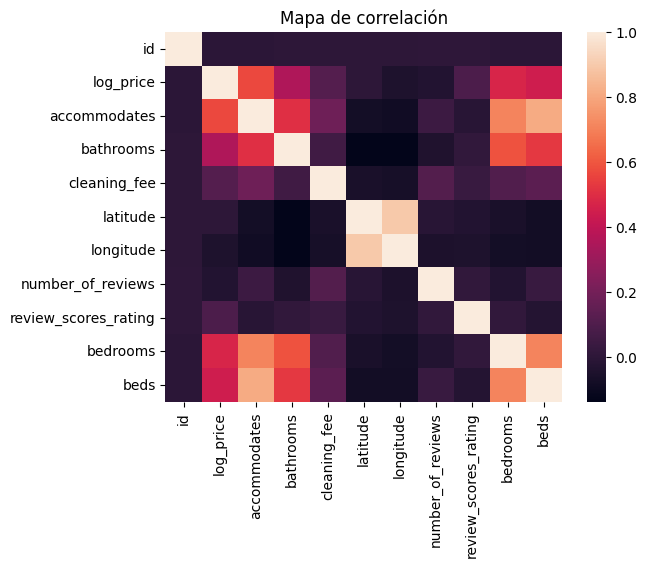

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)
plt.title("Mapa de correlación")
plt.show()

In [12]:
df.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64

In [13]:
df = df.drop(columns=["thumbnail_url", "id", "name"])

In [14]:
df["host_response_rate"] = df["host_response_rate"].str.replace("%", "")
df["host_response_rate"] = pd.to_numeric(df["host_response_rate"], errors="coerce")

In [15]:
df["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].mean())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["beds"] = df["beds"].fillna(df["beds"].median())
df["host_response_rate"] = df["host_response_rate"].fillna(df["host_response_rate"].mean())

In [16]:
df = pd.get_dummies(df, columns=["room_type", "city"], drop_first=True)

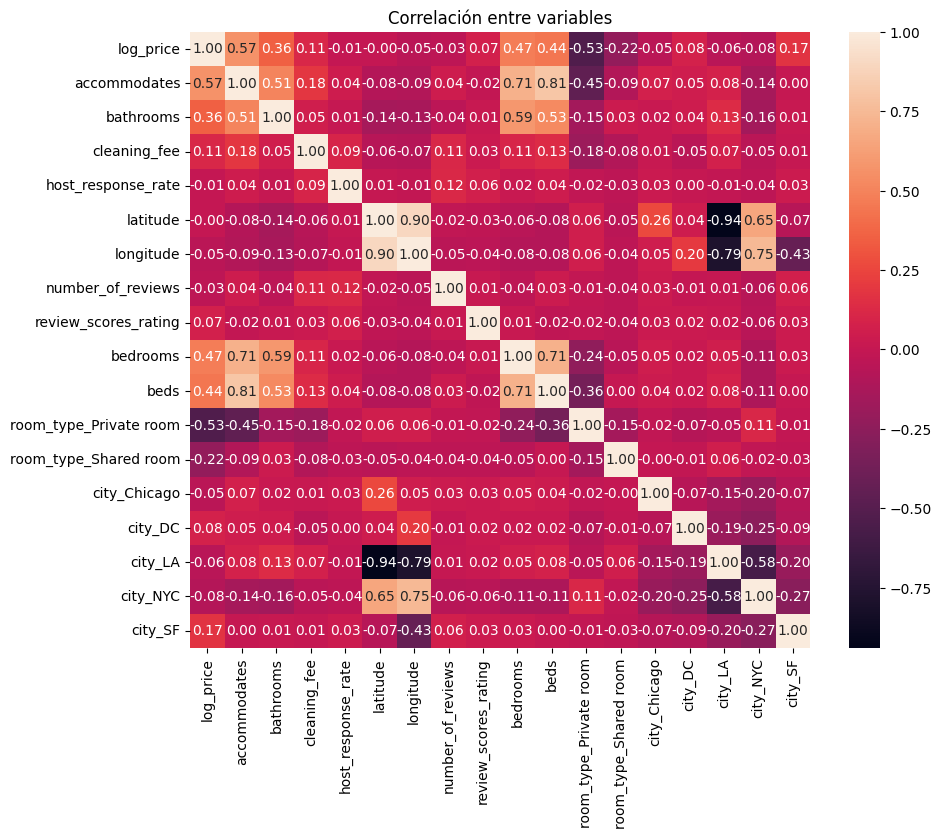

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlación entre variables")
plt.show()

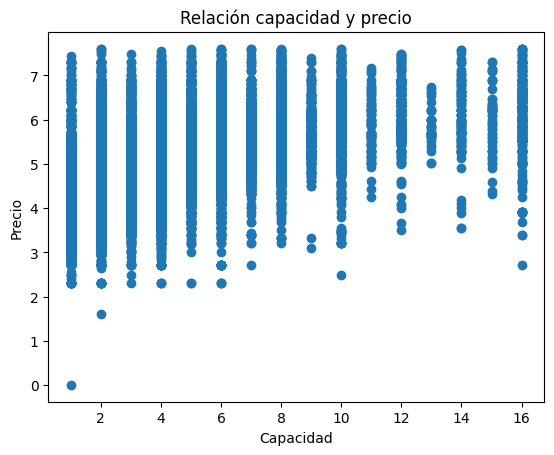

In [18]:
plt.scatter(df["accommodates"], df["log_price"])
plt.xlabel("Capacidad")
plt.ylabel("Precio")
plt.title("Relación capacidad y precio")
plt.show()

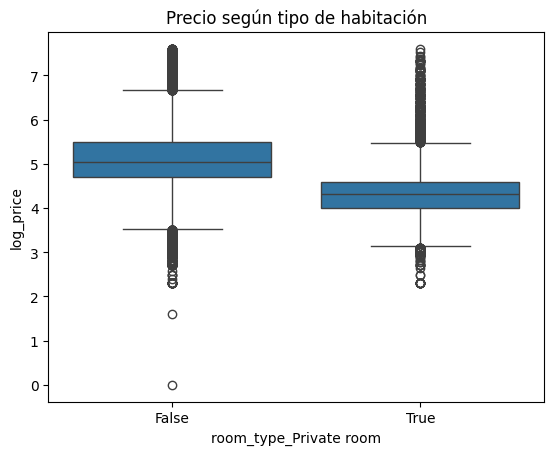

In [19]:
sns.boxplot(x="room_type_Private room", y="log_price", data=df)
plt.title("Precio según tipo de habitación")
plt.show()

In [20]:
X = df[["accommodates", "bathrooms", "bedrooms", "beds", "review_scores_rating"]]
y = df["log_price"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

ModuleNotFoundError: No module named 'sklearn'

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

ModuleNotFoundError: No module named 'sklearn'

In [23]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 22.7 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 23.6 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]


In [26]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [29]:
X = df[["accommodates", "bathrooms", "bedrooms", "beds", "review_scores_rating"]]
y = df["log_price"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
print(model.score(X_test, y_test))

0.32731724267858475


In [33]:
print("R²:", model.score(X_test, y_test))

R²: 0.32731724267858475


In [34]:
y_pred = model.predict(X_test)

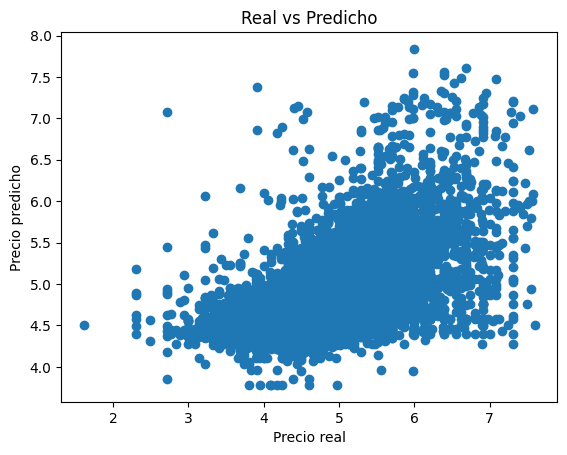

In [35]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Real vs Predicho")
plt.show()

In [36]:
X = df[[
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "host_response_rate"
]]

In [37]:
X = df[[
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "host_response_rate",
    "number_of_reviews",
    "cleaning_fee"
]]

In [38]:
df["cleaning_fee"] = df["cleaning_fee"].astype(int)

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
print("R²:", model.score(X_test, y_test))

R²: 0.3492690243592421


In [41]:
df = pd.get_dummies(df, columns=["room_type", "city"], drop_first=True)

KeyError: "None of [Index(['room_type', 'city'], dtype='str')] are in the [columns]"

In [42]:
df.columns

Index(['log_price', 'property_type', 'amenities', 'accommodates', 'bathrooms',
       'bed_type', 'cancellation_policy', 'cleaning_fee', 'description',
       'first_review', 'host_has_profile_pic', 'host_identity_verified',
       'host_response_rate', 'host_since', 'instant_bookable', 'last_review',
       'latitude', 'longitude', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds',
       'room_type_Private room', 'room_type_Shared room', 'city_Chicago',
       'city_DC', 'city_LA', 'city_NYC', 'city_SF'],
      dtype='str')

In [43]:
df = pd.get_dummies(df, columns=["room_type", "city"], drop_first=True)

KeyError: "None of [Index(['room_type', 'city'], dtype='str')] are in the [columns]"

EVIDENCIA DE ACTIVIDADES - SEMANA 3

ACTIVIDAD 3.1: REFUERZO DE PYTHON
Lista de números: [1, 2, 3, 4, 5]
Cuadrados: [1, 4, 9, 16, 25]
Diccionario: {'nombre': 'Ana', 'edad': 20, 'carrera': 'Ingeniería en Sistemas'}
Suma con lambda (5 + 3): 8
Resultado de la división: 5.0

Importando librerías...
Librerías importadas correctamente.

ACTIVIDAD 3.2: CARGA Y EXPLORACIÓN DE DATOS
Dataset cargado correctamente.

Primeras filas del dataset:


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0



Dimensiones del dataset: (74111, 29)

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000



Valores nulos por columna:
id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64

ACTIVIDAD 3.3: LIMPIEZA DE DAT

/tmp/ipykernel_24389/3738685654.py:95: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_limpio["review_scores_rating"].fillna(


Dimensiones después de la limpieza: (74111, 29)

Valores nulos después de la limpieza:
id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds             

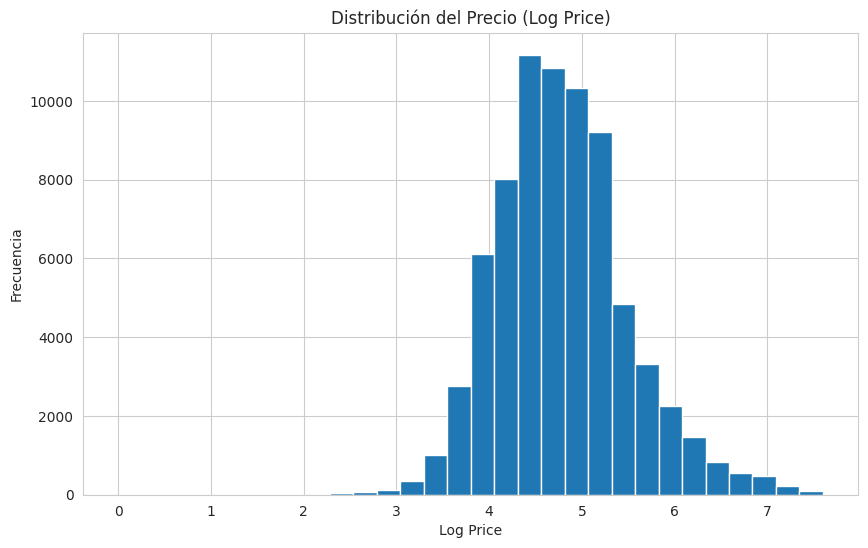

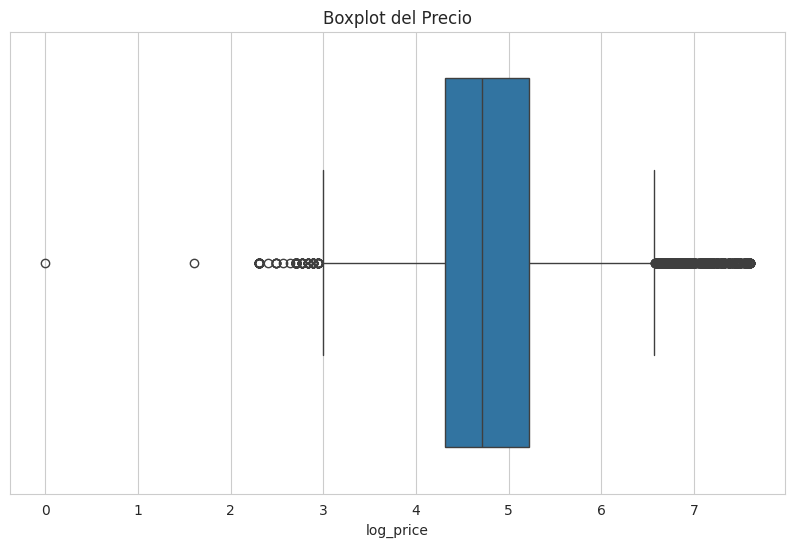

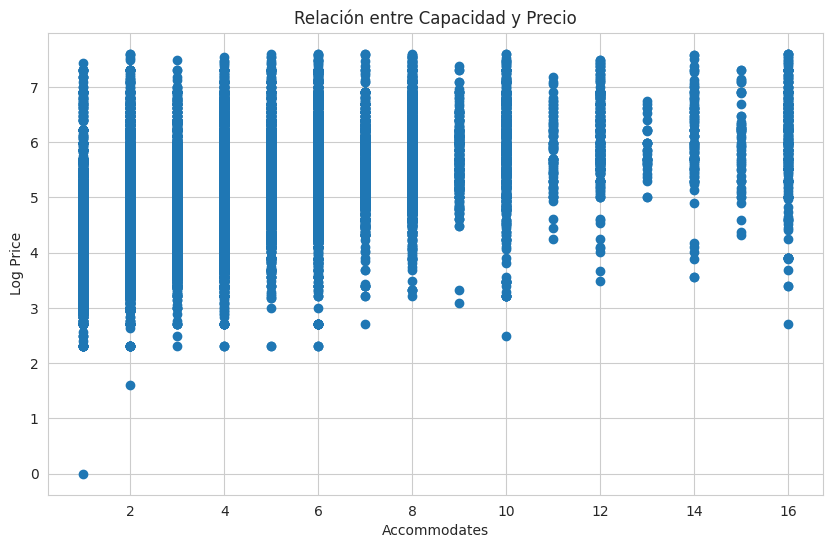

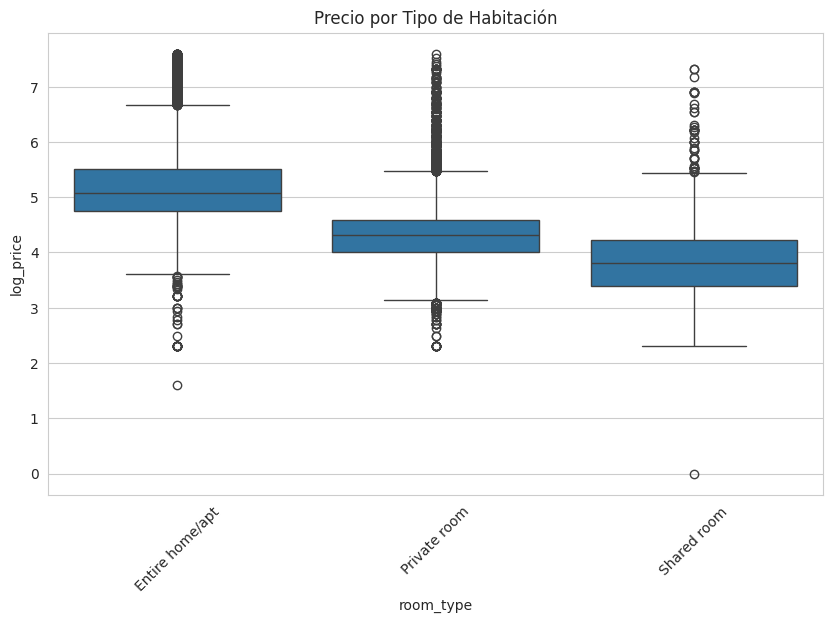

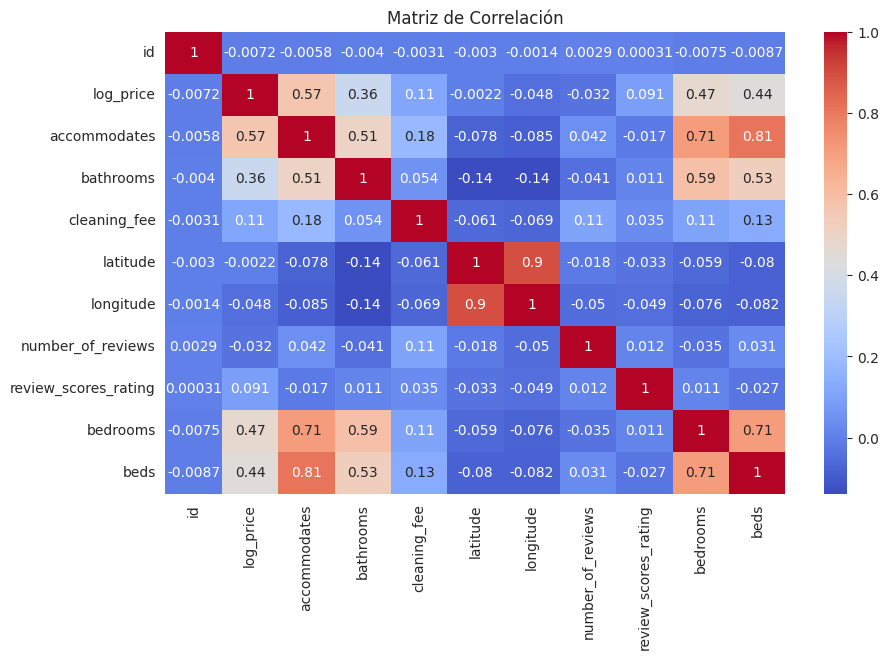


ANÁLISIS ESTADÍSTICO

Media:
id                      1.126662e+07
log_price               4.782069e+00
accommodates            3.155146e+00
bathrooms               1.235263e+00
cleaning_fee            7.340746e-01
latitude                3.844596e+01
longitude              -9.239753e+01
number_of_reviews       2.090057e+01
review_scores_rating    9.406736e+01
bedrooms                1.265793e+00
beds                    1.710868e+00
dtype: float64

Mediana:
id                      1.225415e+07
log_price               4.709530e+00
accommodates            2.000000e+00
bathrooms               1.000000e+00
cleaning_fee            1.000000e+00
latitude                4.066214e+01
longitude              -7.699696e+01
number_of_reviews       6.000000e+00
review_scores_rating    9.600000e+01
bedrooms                1.000000e+00
beds                    1.000000e+00
dtype: float64

Desviación estándar:
id                      6.081735e+06
log_price               7.173938e-01
accommodates        

In [44]:
# ================================================================
# EVIDENCIA COMPLETA - SEMANA 3
# Python y Análisis Exploratorio de Datos
# Este script integra todas las actividades prácticas para capturas
# de evidencia en una sola ejecución.
# ================================================================

print("="*70)
print("EVIDENCIA DE ACTIVIDADES - SEMANA 3")
print("="*70)

# ================================================================
# ACTIVIDAD 3.1: REFUERZO DE PYTHON
# ================================================================
print("\nACTIVIDAD 3.1: REFUERZO DE PYTHON")

# Listas y List Comprehension
numeros = [1, 2, 3, 4, 5]
cuadrados = [n**2 for n in numeros]

# Diccionario
estudiante = {
    "nombre": "Ana",
    "edad": 20,
    "carrera": "Ingeniería en Sistemas"
}

# Función Lambda
suma = lambda a, b: a + b

# Manejo de errores
try:
    division = 10 / 2
except ZeroDivisionError:
    division = "Error: División entre cero"

print("Lista de números:", numeros)
print("Cuadrados:", cuadrados)
print("Diccionario:", estudiante)
print("Suma con lambda (5 + 3):", suma(5, 3))
print("Resultado de la división:", division)

# ================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ================================================================
print("\nImportando librerías...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

print("Librerías importadas correctamente.")

# ================================================================
# ACTIVIDAD 3.2: CARGA Y EXPLORACIÓN DE DATOS
# ================================================================
print("\nACTIVIDAD 3.2: CARGA Y EXPLORACIÓN DE DATOS")

try:
    df = pd.read_csv("train.csv")
    print("Dataset cargado correctamente.\n")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'train.csv'.")
    raise

print("Primeras filas del dataset:")
display(df.head())

print("\nDimensiones del dataset:", df.shape)

print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nValores nulos por columna:")
print(df.isnull().sum())

# ================================================================
# ACTIVIDAD 3.3: LIMPIEZA DE DATOS
# ================================================================
print("\nACTIVIDAD 3.3: LIMPIEZA DE DATOS")

df_limpio = df.copy()

# Eliminación de duplicados
df_limpio.drop_duplicates(inplace=True)

# Relleno de valores nulos en una columna relevante
if "review_scores_rating" in df_limpio.columns:
    df_limpio["review_scores_rating"].fillna(
        df_limpio["review_scores_rating"].mean(), inplace=True
    )

# Conversión de variables categóricas
for col in ["room_type", "city"]:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].astype("category")

print("Dimensiones después de la limpieza:", df_limpio.shape)

print("\nValores nulos después de la limpieza:")
print(df_limpio.isnull().sum())

# ================================================================
# ACTIVIDAD 3.4: VISUALIZACIÓN EXPLORATORIA
# ================================================================
print("\nACTIVIDAD 3.4: VISUALIZACIÓN EXPLORATORIA")

# Histograma del precio
if "log_price" in df_limpio.columns:
    plt.figure()
    plt.hist(df_limpio["log_price"], bins=30)
    plt.title("Distribución del Precio (Log Price)")
    plt.xlabel("Log Price")
    plt.ylabel("Frecuencia")
    plt.show()

# Boxplot del precio
if "log_price" in df_limpio.columns:
    plt.figure()
    sns.boxplot(x=df_limpio["log_price"])
    plt.title("Boxplot del Precio")
    plt.show()

# Gráfico de dispersión
if "accommodates" in df_limpio.columns and "log_price" in df_limpio.columns:
    plt.figure()
    plt.scatter(df_limpio["accommodates"], df_limpio["log_price"])
    plt.title("Relación entre Capacidad y Precio")
    plt.xlabel("Accommodates")
    plt.ylabel("Log Price")
    plt.show()

# Boxplot por tipo de habitación
if "room_type" in df_limpio.columns and "log_price" in df_limpio.columns:
    plt.figure()
    sns.boxplot(x="room_type", y="log_price", data=df_limpio)
    plt.title("Precio por Tipo de Habitación")
    plt.xticks(rotation=45)
    plt.show()

# Mapa de calor de correlación
plt.figure()
sns.heatmap(df_limpio.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

# ================================================================
# ANÁLISIS ESTADÍSTICO
# ================================================================
print("\nANÁLISIS ESTADÍSTICO")

print("\nMedia:")
print(df_limpio.mean(numeric_only=True))

print("\nMediana:")
print(df_limpio.median(numeric_only=True))

print("\nDesviación estándar:")
print(df_limpio.std(numeric_only=True))

# ================================================================
# CONCLUSIÓN
# ================================================================
print("\n" + "="*70)
print("CONCLUSIÓN")
print("="*70)
print("""
Se completaron satisfactoriamente todas las actividades de la Semana 3:
- Refuerzo de Python.
- Carga y exploración de datos.
- Limpieza del dataset.
- Análisis exploratorio de datos.
- Generación de visualizaciones.

Este análisis permitió identificar patrones y relaciones significativas
entre las variables, sentando las bases para la construcción de modelos
predictivos en futuras etapas del proyecto de ciencia de datos.
""")

print("="*70)
print("FIN DE LA EVIDENCIA")
print("="*70)

EJERCICIOS COMPLEMENTARIOS - SEMANA 3

EJERCICIO 1: VARIABLES Y TIPOS DE DATOS
Tipos de datos:
<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>
<class 'list'>
<class 'dict'>

Conversión de tipos:
10 10.0 3
El usuario tiene 21 años

EJERCICIO 2: CONTROL DE FLUJO
El número es negativo
Seleccionaste la opción 2

Iteración con for:
10
20
30
40

Cálculo del factorial con while:
Factorial: 120

EJERCICIO 3: FUNCIONES
Área del círculo: 78.53981633974483
Fahrenheit: 86.0
Promedio: 9.0
Máximo y mínimo: (8, 2)

EJERCICIO 4: OPERACIONES CON NUMPY
Suma: [6 6 6 6 6]
Multiplicación por escalar: [ 2  4  6  8 10]
Media: 3.0
Mediana: 3.0
Desviación estándar: 1.4142135623730951
Valores únicos: [1 2 3 4 5]
Reshape: [[1 2 3 4 5]]

EJERCICIO 5: ÁLGEBRA CON NUMPY
Producto punto: 32
Producto cruz: [-3  6 -3]
Magnitud v1: 3.7416573867739413
Magnitud v2: 8.774964387392123
Normalización v1: [0.26726124 0.53452248 0.80178373]
Normalización v2: [0.45584231 0.56980288 0.68376346]

EJERCICIO 6: DATAFRAMES

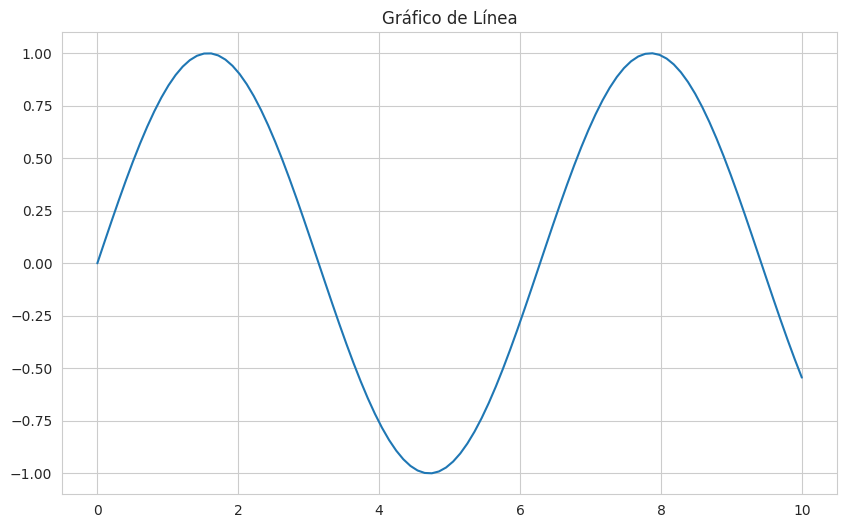

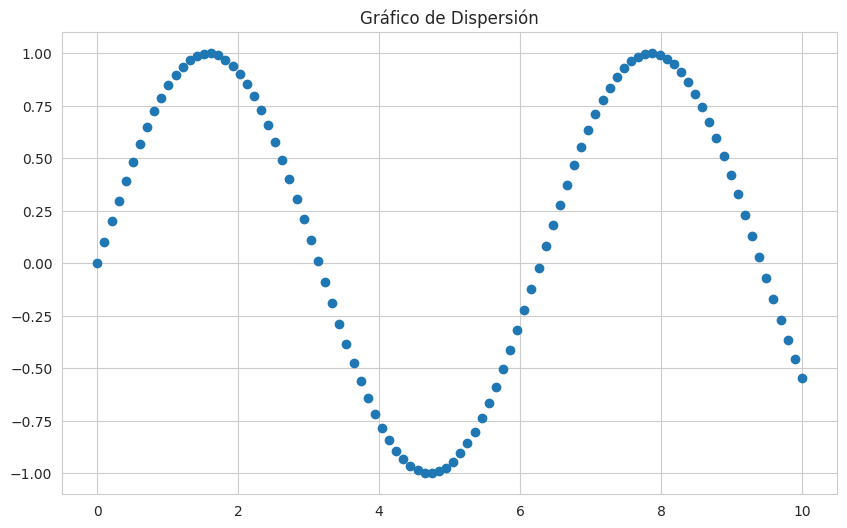

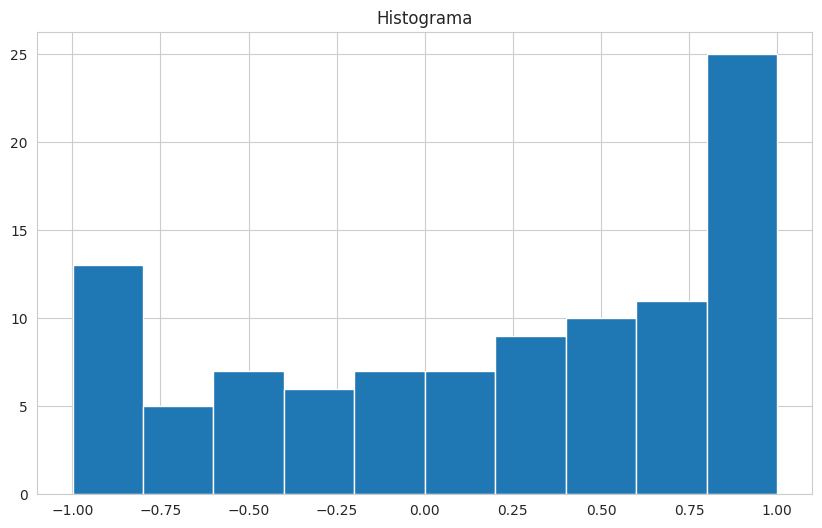

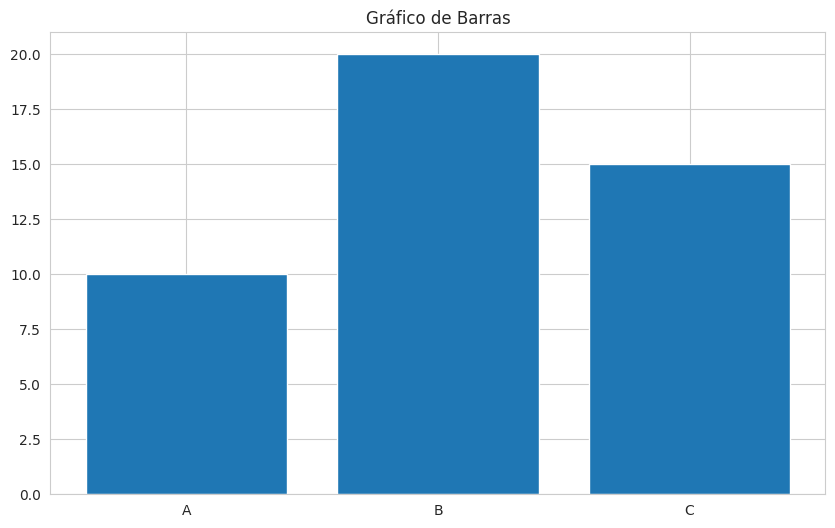


EJERCICIO 9: ANÁLISIS EXPLORATORIO DE DATOS

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Estadísticas descriptivas:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000  

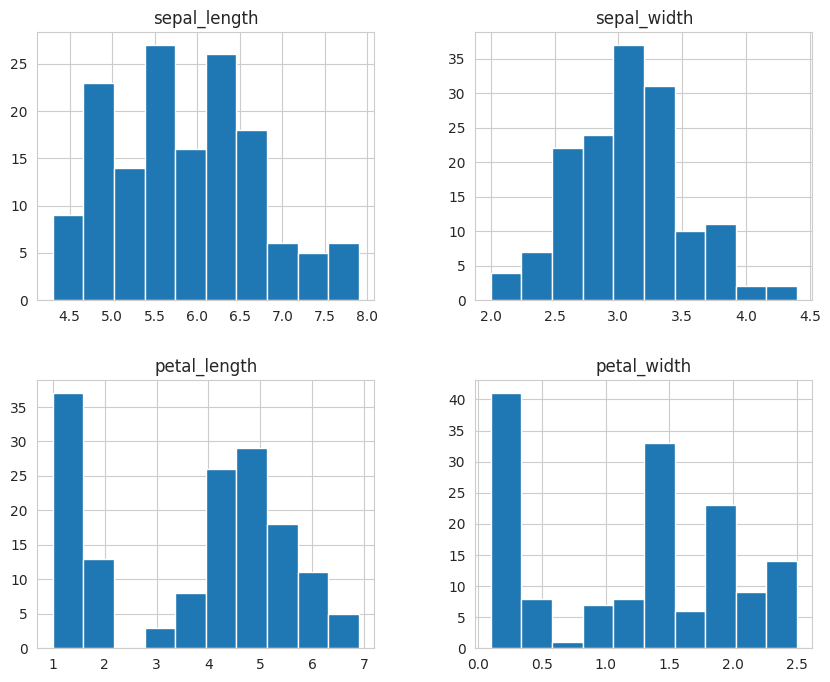

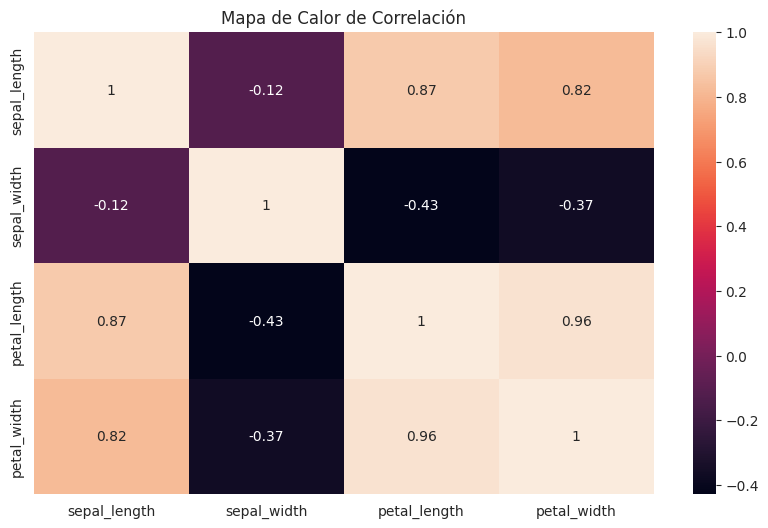

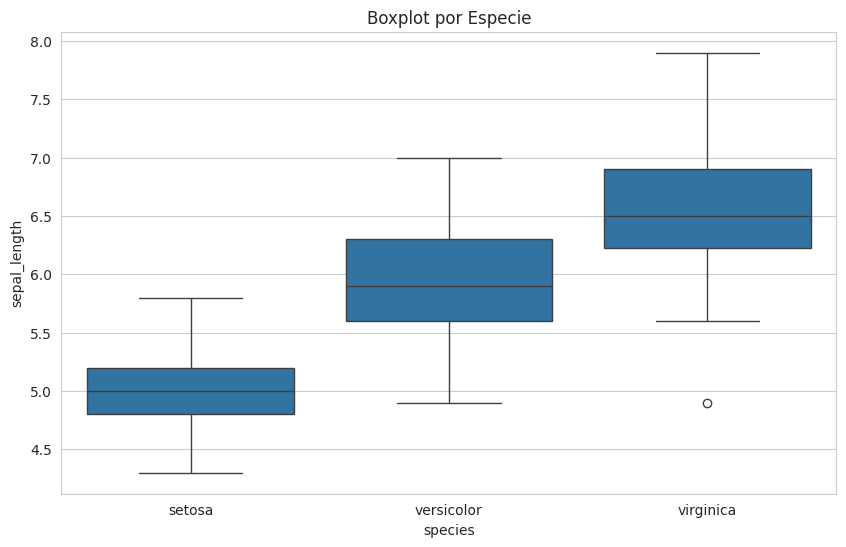


EJERCICIO 10: MEDIDAS DE TENDENCIA CENTRAL
Datos: [5, 3, 8, 3, 7] -> Media: 5.2, Mediana: 5, Moda: 3
Datos: [10, 20, 30, 40] -> Media: 25, Mediana: 25, Moda: No hay
Datos: [1, 2, 2, 3, 3, 3, 4] -> Media: 2.57, Mediana: 3, Moda: 3

EJERCICIO 11: MEDIDAS DE DISPERSIÓN
Datos: [2, 4, 4, 4, 5, 5, 7, 9] -> Rango: 7, Varianza: 4, Desviación Estándar: 2
Datos: [1, 3, 5, 7, 9] -> Rango: 8, Varianza: 8, Desviación Estándar: 2.83

EJERCICIO 12: PROCESO DE DATA SCIENCE

CRISP-DM:
1. Comprensión del negocio
2. Comprensión de los datos
3. Preparación de los datos
4. Modelado
5. Evaluación
6. Despliegue

MVP: Producto mínimo viable que permite validar una solución.


EJERCICIO 13: CASO DE ESTUDIO - AIRBNB

Preguntas clave: ¿Qué factores influyen en el precio?
Técnicas utilizadas: EDA, regresión lineal y visualización.
Insights:
- La ubicación influye significativamente en el precio.
- El tipo de propiedad y el número de habitaciones son determinantes.
- Las calificaciones afectan la percepción del v

In [45]:
# ============================================================
# EJERCICIOS COMPLEMENTARIOS - SEMANA 3
# Temas: T6, T7, T8
# Python para Ciencia de Datos, Proceso de Data Science y EDA
# ============================================================

print("="*70)
print("EJERCICIOS COMPLEMENTARIOS - SEMANA 3")
print("="*70)

# ============================================================
# EJERCICIO 1: VARIABLES Y TIPOS DE DATOS
# ============================================================
print("\nEJERCICIO 1: VARIABLES Y TIPOS DE DATOS")

entero = 25
flotante = 3.1416
cadena = "Ana"
booleano = True
lista = [1, 2, 3, 4]
diccionario = {"nombre": "Ana", "edad": 25}

print("Tipos de datos:")
print(type(entero))
print(type(flotante))
print(type(cadena))
print(type(booleano))
print(type(lista))
print(type(diccionario))

numero_str = "10"
numero_int = int(numero_str)
numero_float = float(numero_int)
numero_entero = int(3.99)

print("\nConversión de tipos:")
print(numero_int, numero_float, numero_entero)

edad = 21
mensaje = f"El usuario tiene {edad} años"
print(mensaje)

# ============================================================
# EJERCICIO 2: CONTROL DE FLUJO
# ============================================================
print("\nEJERCICIO 2: CONTROL DE FLUJO")

numero = -5
if numero > 0:
    print("El número es positivo")
elif numero < 0:
    print("El número es negativo")
else:
    print("El número es cero")

opcion = 2
if opcion == 1:
    print("Seleccionaste la opción 1")
elif opcion == 2:
    print("Seleccionaste la opción 2")
else:
    print("Opción no válida")

print("\nIteración con for:")
lista = [10, 20, 30, 40]
for elemento in lista:
    print(elemento)

print("\nCálculo del factorial con while:")
n = 5
factorial = 1
contador = 1
while contador <= n:
    factorial *= contador
    contador += 1
print("Factorial:", factorial)

# ============================================================
# EJERCICIO 3: FUNCIONES
# ============================================================
print("\nEJERCICIO 3: FUNCIONES")
import math

def area_circulo(radio):
    return math.pi * radio**2

def celsius_a_fahrenheit(celsius):
    return (celsius * 9/5) + 32

def promedio(lista):
    return sum(lista) / len(lista)

def max_min(lista):
    return max(lista), min(lista)

print("Área del círculo:", area_circulo(5))
print("Fahrenheit:", celsius_a_fahrenheit(30))
print("Promedio:", promedio([8, 9, 10]))
print("Máximo y mínimo:", max_min([2, 4, 6, 8]))

# ============================================================
# EJERCICIOS DE NUMPY
# ============================================================
print("\nEJERCICIO 4: OPERACIONES CON NUMPY")
import numpy as np

arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.array([5, 4, 3, 2, 1])

print("Suma:", arr1 + arr2)
print("Multiplicación por escalar:", arr1 * 2)
print("Media:", np.mean(arr1))
print("Mediana:", np.median(arr1))
print("Desviación estándar:", np.std(arr1))
print("Valores únicos:", np.unique(arr1))
print("Reshape:", arr1.reshape(1, 5))

print("\nEJERCICIO 5: ÁLGEBRA CON NUMPY")
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])

print("Producto punto:", np.dot(v1, v2))
print("Producto cruz:", np.cross(v1, v2))
print("Magnitud v1:", np.linalg.norm(v1))
print("Magnitud v2:", np.linalg.norm(v2))
print("Normalización v1:", v1 / np.linalg.norm(v1))
print("Normalización v2:", v2 / np.linalg.norm(v2))

# ============================================================
# EJERCICIOS DE PANDAS
# ============================================================
print("\nEJERCICIO 6: DATAFRAMES CON PANDAS")
import pandas as pd

data = {
    'nombre': ['Ana', 'Luis', 'María', 'Carlos', 'Sofia'],
    'edad': [20, 22, 19, 21, 23],
    'carrera': ['Ing', 'Ing', 'Lic', 'Ing', 'Lic'],
    'promedio': [8.5, 9.0, 7.8, 8.2, 9.5]
}

df = pd.DataFrame(data)
print("\nDataFrame:")
print(df)

print("\nColumna nombre:")
print(df['nombre'])

print("\nEstudiantes con promedio > 8.5:")
print(df[df['promedio'] > 8.5])

print("\nOrdenado por edad:")
print(df.sort_values(by='edad'))

df['aprobado'] = df['promedio'] >= 7
print("\nPromedio por carrera:")
print(df.groupby('carrera')['promedio'].mean())

print("\nEJERCICIO 7: MANIPULACIÓN DE DATOS")

df.loc[2, 'promedio'] = None
df['promedio'] = df['promedio'].fillna(df['promedio'].mean())
df = df.drop_duplicates()
df['edad_doble'] = df['edad'].apply(lambda x: x * 2)

print("\nSlicing con loc:")
print(df.loc[0:2])

print("\nSlicing con iloc:")
print(df.iloc[0:3])

df2 = df.copy()
df_concatenado = pd.concat([df, df2])
print("\nDataFrame concatenado:")
print(df_concatenado)

# ============================================================
# EJERCICIOS DE VISUALIZACIÓN
# ============================================================
import matplotlib.pyplot as plt

print("\nEJERCICIO 8: VISUALIZACIONES CON MATPLOTLIB")

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure()
plt.plot(x, y)
plt.title("Gráfico de Línea")
plt.show()

plt.figure()
plt.scatter(x, y)
plt.title("Gráfico de Dispersión")
plt.show()

plt.figure()
plt.hist(y)
plt.title("Histograma")
plt.show()

categorias = ['A', 'B', 'C']
valores = [10, 20, 15]

plt.figure()
plt.bar(categorias, valores)
plt.title("Gráfico de Barras")
plt.show()

# ============================================================
# EJERCICIO 9: ANÁLISIS EXPLORATORIO
# ============================================================
print("\nEJERCICIO 9: ANÁLISIS EXPLORATORIO DE DATOS")
import seaborn as sns

iris = sns.load_dataset('iris')

print("\nInformación del dataset:")
print(iris.info())

print("\nEstadísticas descriptivas:")
print(iris.describe())

iris.hist(figsize=(10, 8))
plt.show()

sns.heatmap(iris.corr(numeric_only=True), annot=True)
plt.title("Mapa de Calor de Correlación")
plt.show()

sns.boxplot(x='species', y='sepal_length', data=iris)
plt.title("Boxplot por Especie")
plt.show()

# ============================================================
# EJERCICIOS DE ESTADÍSTICA
# ============================================================
print("\nEJERCICIO 10: MEDIDAS DE TENDENCIA CENTRAL")

print("Datos: [5, 3, 8, 3, 7] -> Media: 5.2, Mediana: 5, Moda: 3")
print("Datos: [10, 20, 30, 40] -> Media: 25, Mediana: 25, Moda: No hay")
print("Datos: [1, 2, 2, 3, 3, 3, 4] -> Media: 2.57, Mediana: 3, Moda: 3")

print("\nEJERCICIO 11: MEDIDAS DE DISPERSIÓN")
print("Datos: [2, 4, 4, 4, 5, 5, 7, 9] -> Rango: 7, Varianza: 4, Desviación Estándar: 2")
print("Datos: [1, 3, 5, 7, 9] -> Rango: 8, Varianza: 8, Desviación Estándar: 2.83")

# ============================================================
# EJERCICIOS DE INVESTIGACIÓN
# ============================================================
print("\nEJERCICIO 12: PROCESO DE DATA SCIENCE")

print("""
CRISP-DM:
1. Comprensión del negocio
2. Comprensión de los datos
3. Preparación de los datos
4. Modelado
5. Evaluación
6. Despliegue

MVP: Producto mínimo viable que permite validar una solución.
""")

print("\nEJERCICIO 13: CASO DE ESTUDIO - AIRBNB")
print("""
Preguntas clave: ¿Qué factores influyen en el precio?
Técnicas utilizadas: EDA, regresión lineal y visualización.
Insights:
- La ubicación influye significativamente en el precio.
- El tipo de propiedad y el número de habitaciones son determinantes.
- Las calificaciones afectan la percepción del valor del alojamiento.
""")

# ============================================================
# FINAL
# ============================================================
print("="*70)
print("TODOS LOS EJERCICIOS COMPLEMENTARIOS HAN SIDO EJECUTADOS")
print("="*70)